In [1]:
import os

count = 0
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        count += 1

        if count >= 5:
            break

    if count >= 5:
        break

/kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols/manifest.jsonl
/kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols/data.yaml
/kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols/classes.txt
/kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols/labels/val/harmonic_filter_224.txt
/kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols/labels/val/contactor_139.txt


In [2]:
from pathlib import Path

def find_symbols_root(base=Path("/kaggle/input")):
    for manifest in base.rglob("manifest.jsonl"):
        root = manifest.parent
        if (root / "images" / "train").exists():
            return root
    raise FileNotFoundError("No component-symbols layout under /kaggle/input")

SYMBOLS = find_symbols_root()
print("SYMBOLS:", SYMBOLS)
print("train PNGs:", len(list((SYMBOLS / "images/train").glob("*.png"))))
print("val PNGs:", len(list((SYMBOLS / "images/val").glob("*.png"))))

SYMBOLS: /kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols
train PNGs: 8320
val PNGs: 2080


In [7]:
import subprocess

result = subprocess.run(
    [
        "git", "clone",
        "https://github.com/ishuu19/Single-Line-Diagram-and-Energy-Mapping.git",
        "/kaggle/working/Single-Line-Diagram-and-Energy-Mapping"
    ],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

Return code: 0
STDOUT: 
STDERR: Cloning into '/kaggle/working/Single-Line-Diagram-and-Energy-Mapping'...



In [8]:

assert (TRAIN_DIR / "train.py").exists(), TRAIN_DIR
print("TRAIN_DIR OK")

TRAIN_DIR OK


In [9]:
import os
import shutil
from pathlib import Path

DEST = REPO / "component-symbols"

if DEST.exists() or DEST.is_symlink():
    if DEST.is_symlink():
        DEST.unlink()
    else:
        shutil.rmtree(DEST)

os.symlink(SYMBOLS, DEST, target_is_directory=True)

for must in ("manifest.jsonl", "classes.txt", "images/train", "images/val"):
    assert (DEST / must).exists(), must

print("Linked:", DEST, "->", SYMBOLS)

Linked: /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/component-symbols -> /kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols


In [1]:
import sys
import tensorflow as tf

%cd "{TRAIN_DIR}"
!pip install -q keras-tuner

sys.path.insert(0, str(TRAIN_DIR))
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

[Errno 2] No such file or directory: '{TRAIN_DIR}'
/kaggle/working


NameError: name 'TRAIN_DIR' is not defined

In [2]:
import os
import sys
import shutil
from pathlib import Path

import tensorflow as tf

# --- 1) Find dataset under /kaggle/input ---
def find_symbols_root(base=Path("/kaggle/input")):
    for manifest in base.rglob("manifest.jsonl"):
        root = manifest.parent
        if (root / "images" / "train").exists():
            return root
    raise FileNotFoundError("No manifest.jsonl + images/train under /kaggle/input")

SYMBOLS = find_symbols_root()
print("SYMBOLS:", SYMBOLS)

# --- 2) Clone repo + training path ---
REPO = Path("/kaggle/working/Single-Line-Diagram-and-Energy-Mapping")
TRAIN_DIR = REPO / "src" / "Object Detection" / "Component Training"

if not (TRAIN_DIR / "train.py").exists():
    !git clone -q https://github.com/ishuu19/Single-Line-Diagram-and-Energy-Mapping.git "{REPO}"

assert (TRAIN_DIR / "train.py").exists(), f"Missing training code: {TRAIN_DIR}"

# --- 3) Link component-symbols for config.py ---
DEST = REPO / "component-symbols"
if DEST.exists() or DEST.is_symlink():
    if DEST.is_symlink():
        DEST.unlink()
    else:
        shutil.rmtree(DEST)
os.symlink(SYMBOLS, DEST, target_is_directory=True)

# --- 4) Install + cwd (use os.chdir, not %cd with braces) ---
os.chdir(TRAIN_DIR)
sys.path.insert(0, str(TRAIN_DIR))

!pip install -q keras-tuner tensorboard

print("cwd:", os.getcwd())
print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

SYMBOLS: /kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols
cwd: /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training
TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
from config import DATA_DIR, REPO_ROOT, DEFAULT_HP
from data import load_datasets

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)

train_ds, val_ds, class_names, class_weights = load_datasets(
    mixup_alpha=DEFAULT_HP["mixup_alpha"]
)
print("classes:", len(class_names))
print("train batches:", int(train_ds.cardinality()))
print("val batches:", int(val_ds.cardinality()))

REPO_ROOT: /kaggle/working/Single-Line-Diagram-and-Energy-Mapping
DATA_DIR: /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/component-symbols


I0000 00:00:1790416759.723318      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790416759.726109      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


classes: 40
train batches: 260
val batches: 65


In [4]:
!python train.py

I0000 00:00:1790416771.028367     185 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13648 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790416771.030547     185 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Epoch 1/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 86s 103ms/step - accuracy: 0.0362 - loss: 3.8246 - top3: 0.1007 - val_accuracy: 0.0250 - val_loss: 3.7730 - val_top3: 0.0750
Epoch 2/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 20s 77ms/step - accuracy: 0.1035 - loss: 3.4190 - top3: 0.2499 - val_accuracy: 0.0990 - val_loss: 3.2253 - val_top3: 0.2817
Epoch 3/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.1839 - loss: 3.0755 - top3: 0.4054 - val_accuracy: 0.0697 - val_loss: 7.9157 - val_top3: 0.1183
Epoch 4/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy:

In [7]:
import config
config.EPOCHS = 10
config.EARLY_STOP_PATIENCE = 5
!python train.py

I0000 00:00:1790421885.984111    6435 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13648 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790421885.986430    6435 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Epoch 1/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 86s 113ms/step - accuracy: 0.0367 - loss: 3.8228 - top3: 0.0998 - val_accuracy: 0.0250 - val_loss: 3.7736 - val_top3: 0.0750
Epoch 2/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy: 0.1030 - loss: 3.4112 - top3: 0.2502 - val_accuracy: 0.0418 - val_loss: 3.8787 - val_top3: 0.1404
Epoch 3/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 20s 79ms/step - accuracy: 0.1900 - loss: 3.0607 - top3: 0.4123 - val_accuracy: 0.0697 - val_loss: 6.8478 - val_top3: 0.1356
Epoch 4/80
260/260 ━━━━━━━━━━━━━━━━━━━━ 21s 79ms/step - accuracy:

In [8]:
!python evaluate.py --model custom

I0000 00:00:1790423602.694068    8520 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13648 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790423602.696440    8520 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 57 variables whereas the saved optimizer has 61 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
{
  "clean": 0.9951923076923077,
  "tta": 0.9951923076923077,
  "degraded": 0.9932692307692308
}
                      precision    recall  f1-score   support

             utility       1.00      1.00      1.00        52
           generator       1.00      1.00      1.00        52


In [9]:
import shutil
from pathlib import Path

out = Path("/kaggle/working/component_train_outputs")
out.mkdir(exist_ok=True)
for name in ("models", "outputs", "logs"):
    src = TRAIN_DIR / name
    if src.exists():
        shutil.copytree(src, out / name, dirs_exist_ok=True)
print("Saved under /kaggle/working/component_train_outputs")

Saved under /kaggle/working/component_train_outputs


In [17]:
!find /kaggle/input -maxdepth 2


/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/anayedeshan


In [21]:
# --- CGHD test-crop evaluation, rebuilt from YOLO labels (no manifest.jsonl needed) ---
from pathlib import Path

import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

from config import IMG_SIZE
from evaluate import predict, most_confused  # model, class_names already in scope

TEST_ROOT = Path("/kaggle/input/datasets/anayedeshan/sld-handwritten-test/component-symbols-test")
labels_dir = TEST_ROOT / "labels" / "test"
images_dir = TEST_ROOT / "images" / "test"
assert labels_dir.is_dir() and images_dir.is_dir(), (labels_dir, images_dir)


# Section 5

In [32]:
# 5.1 paths (safe to re-run after a kernel restart)
import os, sys, shutil
from pathlib import Path

REPO = Path("/kaggle/working/Single-Line-Diagram-and-Energy-Mapping")
TRAIN_DIR = REPO / "src" / "Object Detection" / "Component Training"
if not (TRAIN_DIR / "train.py").exists():
    !git clone -q https://github.com/ishuu19/Single-Line-Diagram-and-Energy-Mapping.git "{REPO}"
assert (TRAIN_DIR / "train.py").exists(), TRAIN_DIR

# training crops (config.py expects REPO/component-symbols)
def find_root(marker_dir, base=Path("/kaggle/input")):
    for manifest in base.rglob("manifest.jsonl"):
        if (manifest.parent / "images" / marker_dir).exists():
            return manifest.parent
    return None

SYMBOLS = find_root("train")
assert SYMBOLS, "training crops not found under /kaggle/input"
DEST = REPO / "component-symbols"
if DEST.is_symlink() or DEST.exists():
    DEST.unlink() if DEST.is_symlink() else shutil.rmtree(DEST)
os.symlink(SYMBOLS, DEST, target_is_directory=True)

# bring a trained model back if the kernel was restarted after training
saved = Path("/kaggle/working/component_train_outputs/models")
if saved.exists():
    (TRAIN_DIR / "models").mkdir(exist_ok=True)
    for f in saved.glob("*.keras"):
        if not (TRAIN_DIR / "models" / f.name).exists():
            shutil.copy(f, TRAIN_DIR / "models" / f.name)

os.chdir(TRAIN_DIR)
sys.path.insert(0, str(TRAIN_DIR))
!pip install -q huggingface_hub
print("cwd:", os.getcwd())
print("models:", sorted(p.name for p in (TRAIN_DIR / "models").glob("*.keras")))


cwd: /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training
models: ['custom.keras', 'custom_best.keras', 'notebook_best.keras']


In [33]:
# 5.2 write config.py into the training folder — adds TEST_DATA_DIR
from pathlib import Path
TRAIN_DIR = Path('/kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training')
(TRAIN_DIR / 'config.py').write_text(r'''from pathlib import Path

REPO_ROOT = Path(__file__).resolve().parents[3]
DATA_DIR = REPO_ROOT / "component-symbols"
MANIFEST_PATH = DATA_DIR / "manifest.jsonl"
CLASSES_PATH = DATA_DIR / "classes.txt"

# External test crops (CGHD → SLD mapping); never used for training
TEST_DATA_DIR = REPO_ROOT / "component-symbols-test"
TEST_MANIFEST_PATH = TEST_DATA_DIR / "manifest.jsonl"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 123

# cosine decay runs to EPOCHS; keep it short enough to finish, early stopping is only a safety net
EPOCHS = 80
WARMUP_EPOCHS = 5
EARLY_STOP_PATIENCE = 30
FREEZE_EPOCHS = 10  # backbone runs: head-only warmup before unfreezing

# scan degradation is applied per sample to this fraction of each batch
DEGRADE_PROB = 0.5

# baseline that reached 96.4% clean val on the first Colab run; `tune.py --mode near` searches around it
DEFAULT_HP = dict(
    learning_rate=1e-3,
    weight_decay=1e-4,
    dropout=0.4,
    width=32,
    label_smoothing=0.1,
    mixup_alpha=0.2,
    degrade_prob=DEGRADE_PROB,
)

BACKBONES = ("efficientnetv2b0", "mobilenetv3small", "convnexttiny")

# geometric: 0.03 of a turn is about ±11°; symbols already come in 0/90/180/270 so only jitter
ROTATION = 0.03
ZOOM = 0.1
TRANSLATION = 0.08
CONTRAST = 0.3
# scan degradation: stand-in for photographed / photocopied real sheets
NOISE = 0.05
BLUR = 1.0
ERASE = 0.25

TUNE_MAX_EPOCHS = 25
TUNE_FACTOR = 3   # Hyperband, --mode wide
TUNE_TRIALS = 12  # Bayesian, --mode near
TTA_PASSES = 8

RUN_DIR = Path(__file__).resolve().parent
MODEL_DIR = RUN_DIR / "models"
OUTPUT_DIR = RUN_DIR / "outputs"
LOG_DIR = RUN_DIR / "logs"
''', encoding='utf-8')
print('wrote', TRAIN_DIR / 'config.py')


wrote /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training/config.py


In [34]:
# 5.2 write data.py into the training folder — adds load_external_test_dataset
from pathlib import Path
TRAIN_DIR = Path('/kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training')
(TRAIN_DIR / 'data.py').write_text(r'''import json

import numpy as np
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

from config import (
    BATCH_SIZE,
    CLASSES_PATH,
    DATA_DIR,
    IMG_SIZE,
    MANIFEST_PATH,
    SEED,
    TEST_DATA_DIR,
    TEST_MANIFEST_PATH,
)


def load_class_names():
    return CLASSES_PATH.read_text().splitlines()


def read_manifest(path=MANIFEST_PATH):
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


def classifier_classes(rows):
    # classes.txt is the detector vocabulary; `text` only appears as a box inside crops, never as a crop
    present = {r["type"] for r in rows}
    return [c for c in load_class_names() if c in present]


def split_arrays(rows, split, class_names, data_dir=DATA_DIR):
    class_to_id = {name: i for i, name in enumerate(class_names)}
    rows = [r for r in rows if r["split"] == split and r["type"] in class_to_id]
    paths = np.array([str(data_dir / r["file"]) for r in rows])
    labels = np.array([class_to_id[r["type"]] for r in rows])
    return paths, labels


def load_arrays():
    rows = read_manifest()
    class_names = classifier_classes(rows)
    train = split_arrays(rows, "train", class_names)
    val = split_arrays(rows, "val", class_names)
    return train, val, class_names


def _load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=1)
    # invert so ink is high and any paper tint collapses toward 0; padding then matches the background
    image = 255.0 - tf.cast(image, tf.float32)
    image = tf.image.resize_with_pad(image, *IMG_SIZE)
    return image, label


def _mixup(alpha):
    def apply(images, labels):
        g1 = tf.random.gamma([], alpha)
        g2 = tf.random.gamma([], alpha)
        lam = g1 / (g1 + g2)
        images = lam * images + (1 - lam) * tf.reverse(images, [0])
        labels = lam * labels + (1 - lam) * tf.reverse(labels, [0])
        return images, labels
    return apply


def make_dataset(paths, labels, num_classes, training, mixup_alpha=0.0):
    onehot = tf.one_hot(labels, num_classes)
    ds = tf.data.Dataset.from_tensor_slices((paths, onehot))
    ds = ds.map(_load_image, num_parallel_calls=tf.data.AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.batch(BATCH_SIZE)
    if training and mixup_alpha > 0:
        ds = ds.map(_mixup(mixup_alpha), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


def class_weights(labels):
    present = np.unique(labels)
    weights = compute_class_weight("balanced", classes=present, y=labels)
    return dict(zip(present.tolist(), weights.tolist()))


def load_datasets(mixup_alpha=0.0):
    (train_paths, train_labels), (val_paths, val_labels), class_names = load_arrays()
    n = len(class_names)
    train_ds = make_dataset(train_paths, train_labels, n, training=True, mixup_alpha=mixup_alpha)
    val_ds = make_dataset(val_paths, val_labels, n, training=False)
    return train_ds, val_ds, class_names, class_weights(train_labels)


def load_external_test_dataset(class_names):
    """CGHD (or other) test crops; labels aligned to the training classifier vocabulary."""
    if not TEST_MANIFEST_PATH.is_file():
        return None
    rows = read_manifest(TEST_MANIFEST_PATH)
    paths, labels = split_arrays(rows, "test", class_names, data_dir=TEST_DATA_DIR)
    if len(paths) == 0:
        return None
    return make_dataset(paths, labels, len(class_names), training=False)
''', encoding='utf-8')
print('wrote', TRAIN_DIR / 'data.py')


wrote /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training/data.py


In [35]:
# 5.2 write evaluate.py into the training folder — adds --split cghd-test
from pathlib import Path
TRAIN_DIR = Path('/kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training')
(TRAIN_DIR / 'evaluate.py').write_text(r'''import argparse
import json
from collections import Counter

import numpy as np
import tensorflow as tf
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

import model as _  # registers RandomDegrade for load_model
from config import MODEL_DIR, OUTPUT_DIR, SEED, TTA_PASSES
from data import load_datasets, load_external_test_dataset


def predict(model, ds, mode="clean"):
    geometric, degrade = model.get_layer("geometric"), model.get_layer("degrade")
    labels, probs = [], []
    for images, y in ds:
        if mode == "degraded":
            images = degrade(images, training=True)
        if mode == "tta":
            # the model's own augmentation is inert at inference, so feed pre-augmented views through it
            views = [images] + [geometric(images, training=True) for _ in range(TTA_PASSES)]
            p = np.mean([tf.nn.softmax(model(v, training=False), -1).numpy() for v in views], axis=0)
        else:
            p = tf.nn.softmax(model(images, training=False), -1).numpy()
        probs.append(p)
        labels.append(np.argmax(y.numpy(), -1))
    return np.concatenate(labels), np.argmax(np.concatenate(probs), -1)


def most_confused(labels, predictions, class_names, n=10):
    pairs = Counter((class_names[t], class_names[p]) for t, p in zip(labels, predictions) if t != p)
    return pairs.most_common(n)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--model", default="custom", help="tag used by train.py, e.g. custom or efficientnetv2b0")
    parser.add_argument(
        "--split",
        choices=("val", "cghd-test"),
        default="val",
        help="val = Schematex val; cghd-test = component-symbols-test (CGHD crops)",
    )
    args = parser.parse_args()

    tf.keras.utils.set_random_seed(SEED)
    _, val_ds, class_names, _ = load_datasets()
    eval_ds = val_ds
    split_tag = "val"
    if args.split == "cghd-test":
        eval_ds = load_external_test_dataset(class_names)
        if eval_ds is None:
            raise SystemExit(
                "component-symbols-test not found. Run build_cghd_test_crops.py from Component Training."
            )
        split_tag = "cghd_test"

    # compile=False: inference only, and skips the stale AdamW state saved with the Colab checkpoint
    model = tf.keras.models.load_model(str(MODEL_DIR / f"{args.model}.keras"), compile=False)

    metrics = {}
    for mode in ("clean", "tta", "degraded"):
        labels, predictions = predict(model, eval_ds, mode)
        metrics[mode] = float(np.mean(labels == predictions))
    print(json.dumps(metrics, indent=2))

    labels, predictions = predict(model, eval_ds, "clean")
    print(classification_report(labels, predictions, target_names=class_names, zero_division=0))
    for (true, pred), count in most_confused(labels, predictions, class_names):
        print(f"{true} -> {pred}: {count}")

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / f"{args.model}_{split_tag}_metrics.json").write_text(json.dumps(metrics, indent=2))
    disp = ConfusionMatrixDisplay.from_predictions(labels, predictions, display_labels=class_names, xticks_rotation=90)
    disp.figure_.set_size_inches(12, 12)
    disp.figure_.savefig(OUTPUT_DIR / f"{args.model}_{split_tag}_confusion_matrix.png", bbox_inches="tight")


if __name__ == "__main__":
    main()
''', encoding='utf-8')
print('wrote', TRAIN_DIR / 'evaluate.py')


wrote /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training/evaluate.py


In [36]:
# 5.2 write cghd_to_sld.json into the training folder — CGHD class -> SLD class
from pathlib import Path
TRAIN_DIR = Path('/kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training')
(TRAIN_DIR / 'cghd_to_sld.json').write_text(r'''{
  "transformer": "transformer",
  "motor": "motor",
  "switch": "switch",
  "relay": "relay",
  "fuse": "fuse",
  "inductor.coupled": "transformer",
  "probe.current": "ct",
  "probe.voltage": "pt"
}
''', encoding='utf-8')
print('wrote', TRAIN_DIR / 'cghd_to_sld.json')


wrote /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training/cghd_to_sld.json


In [37]:
# 5.2 write build_cghd_test_crops.py into the training folder
from pathlib import Path
TRAIN_DIR = Path('/kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training')
(TRAIN_DIR / 'build_cghd_test_crops.py').write_text(r'''"""
Export test-only symbol crops from CGHD (DFKI, CC0) — not Schematex.

Source: https://huggingface.co/datasets/lowercaseonly/cghd
Maps a small subset of CGHD classes onto our SLD vocabulary (see cghd_to_sld.json).

Usage (from repo root or this folder):
  python build_cghd_test_crops.py
  python build_cghd_test_crops.py --max-crops 500 --pad 0.12

Output: component-symbols-test/  (images/test, labels/test, manifest.jsonl)
"""

from __future__ import annotations

import argparse
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import time

from huggingface_hub import hf_hub_download, snapshot_download
from huggingface_hub.errors import HfHubHTTPError
from PIL import Image

REPO_ROOT = Path(__file__).resolve().parents[3]
OUT_DIR = REPO_ROOT / "component-symbols-test"
MAP_PATH = Path(__file__).resolve().parent / "cghd_to_sld.json"
HF_REPO = "lowercaseonly/cghd"

# Same order as Synthetic Data/_tools/components.mjs
SLD_TYPES = [
    "utility", "generator", "solar", "wind", "ups",
    "transformer", "transformer_dy", "transformer_yd", "transformer_yy", "transformer_dd",
    "autotransformer", "transformer_3winding",
    "bus", "bus_tie", "hub",
    "breaker", "breaker_vacuum", "switch", "switch_load", "contactor", "ground_switch",
    "ats", "recloser", "sectionalizer", "fuse", "fuse_cl",
    "ct", "pt", "relay", "surge_arrester", "ground_fault", "rcd",
    "motor", "load", "capacitor_bank", "harmonic_filter", "vfd",
    "watthour_meter", "demand_meter", "consumer_unit",
]
TEXT_CLASS = "text"
CLASSES = SLD_TYPES + [TEXT_CLASS]
CLASS_ID = {name: i for i, name in enumerate(CLASSES)}


def parse_voc_objects(xml_text: str):
    root = ET.fromstring(xml_text)
    filename = root.findtext("filename") or ""
    size = root.find("size")
    w = int(size.findtext("width") or 0) if size is not None else 0
    h = int(size.findtext("height") or 0) if size is not None else 0
    objects = []
    for obj in root.findall("object"):
        name = (obj.findtext("name") or "").strip()
        box = obj.find("bndbox")
        if box is None:
            continue
        xmin = int(float(box.findtext("xmin") or 0))
        ymin = int(float(box.findtext("ymin") or 0))
        xmax = int(float(box.findtext("xmax") or 0))
        ymax = int(float(box.findtext("ymax") or 0))
        objects.append({"name": name, "bbox": (xmin, ymin, xmax, ymax)})
    return filename, w, h, objects


def annotation_to_image_path(ann_path: Path, filename: str) -> Path:
    # .../drafter_-1/annotations/C-10_D1_P1.xml -> .../drafter_-1/images/C-10_D1_P1.jpg
    return ann_path.parent.parent / "images" / filename


def default_hf_cache_root() -> Path | None:
    hub = Path.home() / ".cache/huggingface/hub/datasets--lowercaseonly--cghd/snapshots"
    if not hub.is_dir():
        return None
    snaps = sorted(hub.iterdir(), key=lambda p: p.stat().st_mtime, reverse=True)
    for snap in snaps:
        if collect_annotations(snap):
            return snap
    return None


def resolve_cghd_root(cghd_root: str | None, *, dry_run: bool) -> Path:
    if cghd_root:
        root = Path(cghd_root)
        if not root.is_dir():
            raise SystemExit(f"--cghd-root not found: {root}")
        return root
    cached = default_hf_cache_root()
    if cached is not None:
        print(f"Using Hugging Face cache: {cached}")
        return cached
    patterns = ["drafter_*/annotations/*.xml"]
    if not dry_run:
        patterns.append("drafter_*/images/*")
    print(f"Downloading CGHD from Hugging Face ({', '.join(patterns)})...")
    print("Tip: set HF_TOKEN or use --cghd-root after a Kaggle/manual download to avoid rate limits.")
    cached = snapshot_download(
        HF_REPO,
        repo_type="dataset",
        allow_patterns=patterns,
        max_workers=4,
    )
    return Path(cached)


def hf_fetch(rel_path: str, retries: int = 6) -> Path | None:
    """Fetch one file into the HF cache (with backoff on 429). Returns None if unavailable."""
    rel = rel_path.replace("\\", "/")
    delay = 3.0
    for attempt in range(retries):
        try:
            return Path(hf_hub_download(HF_REPO, rel, repo_type="dataset"))
        except HfHubHTTPError as exc:
            code = exc.response.status_code if exc.response is not None else None
            if code == 429 and attempt < retries - 1:
                print(f"HF rate limit; waiting {delay:.0f}s ({rel})...")
                time.sleep(delay)
                delay = min(delay * 1.8, 120.0)
                continue
            return None
        except Exception:
            return None
    return None


def collect_annotations(root: Path) -> list[Path]:
    return sorted(root.glob("drafter_*/annotations/*.xml"))


def pad_bbox(bbox, width, height, pad_frac):
    xmin, ymin, xmax, ymax = bbox
    bw = max(xmax - xmin, 1)
    bh = max(ymax - ymin, 1)
    px = bw * pad_frac
    py = bh * pad_frac
    xmin = max(0, int(xmin - px))
    ymin = max(0, int(ymin - py))
    xmax = min(width, int(xmax + px))
    ymax = min(height, int(ymax + py))
    return xmin, ymin, xmax, ymax


def yolo_symbol_line(class_name: str, crop_w: int, crop_h: int, inner_bbox):
    """Single symbol box in crop coordinates (normalized)."""
    ix0, iy0, ix1, iy1 = inner_bbox
    cx = (ix0 + ix1) / 2 / crop_w
    cy = (iy0 + iy1) / 2 / crop_h
    bw = (ix1 - ix0) / crop_w
    bh = (iy1 - iy0) / crop_h
    cid = CLASS_ID[class_name]
    return f"{cid} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}"


def main():
    parser = argparse.ArgumentParser(description="Build CGHD test crops under component-symbols-test/")
    parser.add_argument("--max-crops", type=int, default=0, help="Stop after N crops (0 = all)")
    parser.add_argument("--pad", type=float, default=0.15, help="Padding around VOC box as fraction of box size")
    parser.add_argument("--min-size", type=int, default=24, help="Skip crops smaller than this (px)")
    parser.add_argument("--dry-run", action="store_true", help="Count mappable boxes only; do not download images")
    parser.add_argument(
        "--max-sheets",
        type=int,
        default=0,
        help="Only process this many annotation XMLs (0 = all; use for quick smoke tests)",
    )
    parser.add_argument(
        "--cghd-root",
        type=str,
        default="",
        help="Local CGHD tree (drafter_*/annotations). Default: download/cache via Hugging Face.",
    )
    parser.add_argument(
        "--refresh",
        action="store_true",
        help="Delete existing images/test and labels/test before writing",
    )
    parser.add_argument(
        "--local-images-only",
        action="store_true",
        help="Only use images already on disk under --cghd-root / HF cache (no Hub downloads)",
    )
    args = parser.parse_args()

    cghd_to_sld = json.loads(MAP_PATH.read_text())
    cghd_root = resolve_cghd_root(args.cghd_root or None, dry_run=args.dry_run)
    ann_files = collect_annotations(cghd_root)
    if args.max_sheets:
        ann_files = ann_files[: args.max_sheets]
    print(f"CGHD root: {cghd_root}")
    print(f"CGHD annotation files to scan: {len(ann_files)}")

    if not args.dry_run:
        img_out = OUT_DIR / "images" / "test"
        lbl_out = OUT_DIR / "labels" / "test"
        if args.refresh and OUT_DIR.exists():
            for sub in (img_out, lbl_out):
                if sub.is_dir():
                    for p in sub.iterdir():
                        p.unlink()
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)

    manifest = []
    image_cache: dict[str, Image.Image] = {}
    crop_idx = 0
    for ann_path in ann_files:
        if args.max_crops and crop_idx >= args.max_crops:
            break
        xml_text = ann_path.read_text(encoding="utf-8")
        filename, _, _, objects = parse_voc_objects(xml_text)
        if not filename:
            continue
        image_path = annotation_to_image_path(ann_path, filename)

        mappable = [o for o in objects if o["name"] in cghd_to_sld]
        if not mappable:
            continue

        if args.dry_run:
            crop_idx += len(mappable)
            continue

        if not image_path.is_file():
            if args.local_images_only:
                continue
            rel_img = str(image_path.relative_to(cghd_root)).replace("\\", "/")
            fetched = hf_fetch(rel_img)
            if fetched is None:
                continue
            image_path = fetched

        cache_key = str(image_path)
        if cache_key not in image_cache:
            image_cache[cache_key] = Image.open(image_path).convert("RGB")
            if len(image_cache) > 32:
                image_cache.pop(next(iter(image_cache)))

        image = image_cache[cache_key]
        iw, ih = image.size

        for obj in mappable:
            if args.max_crops and crop_idx >= args.max_crops:
                break
            sld_type = cghd_to_sld[obj["name"]]
            x0, y0, x1, y1 = pad_bbox(obj["bbox"], iw, ih, args.pad)
            if x1 - x0 < args.min_size or y1 - y0 < args.min_size:
                continue

            crop = image.crop((x0, y0, x1, y1))
            cw, ch = crop.size
            inner = (
                obj["bbox"][0] - x0,
                obj["bbox"][1] - y0,
                obj["bbox"][2] - x0,
                obj["bbox"][3] - y0,
            )
            stem = f"cghd_{crop_idx:05d}"
            png_path = OUT_DIR / "images" / "test" / f"{stem}.png"
            gray = crop.convert("L")
            gray.save(png_path)

            label_line = yolo_symbol_line(sld_type, cw, ch, inner)
            (OUT_DIR / "labels" / "test" / f"{stem}.txt").write_text(label_line + "\n")

            manifest.append(
                {
                    "file": f"images/test/{stem}.png",
                    "split": "test",
                    "type": sld_type,
                    "source": "cghd",
                    "source_class": obj["name"],
                    "source_image": filename,
                    "source_annotation": str(ann_path.relative_to(cghd_root)).replace("\\", "/"),
                    "bbox_voc": obj["bbox"],
                }
            )
            crop_idx += 1

    if args.dry_run:
        print(f"Mappable crops (estimate): {crop_idx}")
        return

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "classes.txt").write_text("\n".join(CLASSES) + "\n")
    (OUT_DIR / "cghd_to_sld.json").write_text(json.dumps(cghd_to_sld, indent=2) + "\n")
    (OUT_DIR / "data.yaml").write_text(
        "\n".join(
            [
                f"path: {OUT_DIR.as_posix()}",
                "train: images/train",
                "val: images/val",
                "test: images/test",
                f"nc: {len(CLASSES)}",
                "names:",
                *[f"  {i}: {name}" for i, name in enumerate(CLASSES)],
                "",
            ]
        )
    )
    (OUT_DIR / "manifest.jsonl").write_text("\n".join(json.dumps(r) for r in manifest) + ("\n" if manifest else ""))
    (OUT_DIR / "README.md").write_text(
        "\n".join(
            [
                "# component-symbols-test",
                "",
                "Held-out **test** crops from [CGHD](https://huggingface.co/datasets/lowercaseonly/cghd) (CC0).",
                "Not generated by Schematex; use only for evaluation, not training.",
                "",
                f"Regenerate: `python \"src/Object Detection/Component Training/build_cghd_test_crops.py\"`",
                "",
                f"Crops: **{len(manifest)}** under `images/test/`.",
                "",
            ]
        )
    )
    print(f"Wrote {len(manifest)} test crops -> {OUT_DIR}")


if __name__ == "__main__":
    main()
''', encoding='utf-8')
print('wrote', TRAIN_DIR / 'build_cghd_test_crops.py')


wrote /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/src/Object Detection/Component Training/build_cghd_test_crops.py


In [38]:
# 5.3 get the CGHD test crops -> REPO/component-symbols-test
import os, shutil, subprocess
from pathlib import Path

TEST_DEST = REPO / "component-symbols-test"
if TEST_DEST.is_symlink() or TEST_DEST.exists():
    TEST_DEST.unlink() if TEST_DEST.is_symlink() else shutil.rmtree(TEST_DEST)

uploaded = find_root("test")  # component-symbols-test.zip attached as a Kaggle dataset?
if uploaded is not None:
    # copy, not symlink: /kaggle/input is read-only and 5.3b rewrites the crops in place
    shutil.copytree(uploaded, TEST_DEST)
    print("Using uploaded test crops:", uploaded)
else:
    # optional HF token from Kaggle secrets (Add-ons -> Secrets -> HF_TOKEN)
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
        print("HF_TOKEN set from Kaggle secrets")
    except Exception:
        print("No HF_TOKEN secret; downloading anonymously")
    # pass 1: annotations only (fast). pass 2 then reuses that cache and fetches
    # only the images that contain mappable symbols, instead of the whole dataset.
    !python build_cghd_test_crops.py --dry-run
    !python build_cghd_test_crops.py --pad 0.12 --refresh

manifest = TEST_DEST / "manifest.jsonl"
assert manifest.is_file(), "no test crops: turn Internet on, or attach component-symbols-test.zip as a dataset"
n = sum(1 for _ in open(manifest))
print("test crops:", n)


No HF_TOKEN secret; downloading anonymously
Using Hugging Face cache: /root/.cache/huggingface/hub/datasets--lowercaseonly--cghd/snapshots/44a246d1dc41758ff46c26bd69dccd43d2055eba
CGHD root: /root/.cache/huggingface/hub/datasets--lowercaseonly--cghd/snapshots/44a246d1dc41758ff46c26bd69dccd43d2055eba
CGHD annotation files to scan: 755
Mappable crops (estimate): 315
Using Hugging Face cache: /root/.cache/huggingface/hub/datasets--lowercaseonly--cghd/snapshots/44a246d1dc41758ff46c26bd69dccd43d2055eba
CGHD root: /root/.cache/huggingface/hub/datasets--lowercaseonly--cghd/snapshots/44a246d1dc41758ff46c26bd69dccd43d2055eba
CGHD annotation files to scan: 755
Wrote 315 test crops -> /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/component-symbols-test
test crops: 315


normalised 315 crops -> /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/component-symbols-test/images/test


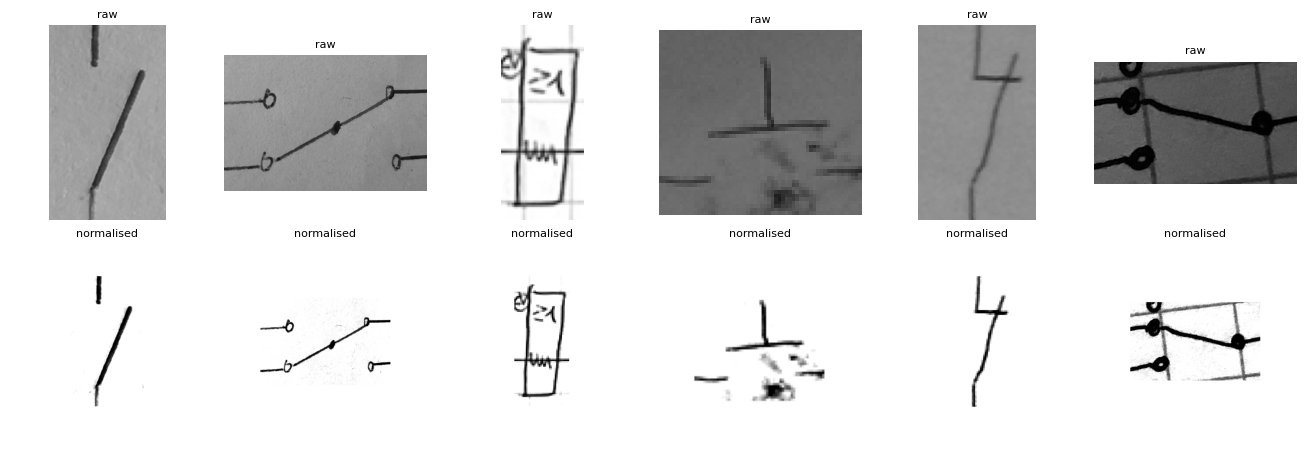

In [39]:
# 5.3b normalise the CGHD crops to the training domain (white paper, black ink, square with margin)
# Idempotent: raw crops are kept in images/test_raw and always used as the source.
import shutil
import numpy as np
from pathlib import Path
from PIL import Image, ImageFilter

TEST_IMG = TEST_DEST / "images" / "test"
TEST_RAW = TEST_DEST / "images" / "test_raw"
if not TEST_RAW.exists():
    shutil.copytree(TEST_IMG, TEST_RAW)

MARGIN = 0.25   # square canvas with paper margin so the symbol fills roughly what a Schematex crop does
PAPER = 0.88    # flattened values above this are paper texture -> snap to pure white
GAMMA = 1.5     # pushes soft pencil strokes toward black

def normalise_crop(img: Image.Image) -> Image.Image:
    g = np.asarray(img.convert("L"), dtype=np.float32)
    h, w = g.shape
    # paper estimate: grey closing (max filter removes thin dark strokes) then blur
    k = max(15, (min(h, w) // 8) | 1)
    paper = Image.fromarray(g.astype(np.uint8)).filter(ImageFilter.MaxFilter(k)).filter(ImageFilter.GaussianBlur(k / 2))
    paper = np.maximum(np.asarray(paper, dtype=np.float32), 1.0)
    flat = np.clip(g / paper, 0, 1)                     # 1 = paper, <1 = ink, independent of lighting
    lo = np.percentile(flat, 1.0)
    stretched = np.clip((flat - lo) / max(PAPER - lo, 1e-3), 0, 1)
    out = Image.fromarray((stretched ** GAMMA * 255).astype(np.uint8))
    side = int(max(h, w) * (1 + 2 * MARGIN))
    canvas = Image.new("L", (side, side), 255)
    canvas.paste(out, ((side - w) // 2, (side - h) // 2))
    return canvas

raw_files = sorted(TEST_RAW.glob("*.png"))
for p in raw_files:
    normalise_crop(Image.open(p)).save(TEST_IMG / p.name)
print(f"normalised {len(raw_files)} crops -> {TEST_IMG}")

# before / after on a few crops
import matplotlib.pyplot as plt
show = raw_files[:: max(1, len(raw_files) // 6)][:6]
fig, axes = plt.subplots(2, len(show), figsize=(2.2 * len(show), 4.6))
for j, p in enumerate(show):
    axes[0, j].imshow(Image.open(p), cmap="gray", vmin=0, vmax=255); axes[0, j].set_title("raw", fontsize=8)
    axes[1, j].imshow(Image.open(TEST_IMG / p.name), cmap="gray", vmin=0, vmax=255); axes[1, j].set_title("normalised", fontsize=8)
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); plt.show()


In [40]:
# 5.5 which model to test: the one trained in this notebook, else the committed Colab checkpoint
from pathlib import Path
have = {p.stem for p in (TRAIN_DIR / "models").glob("*.keras")}
model_tag = next(t for t in ("custom_best", "custom", "notebook_best") if t in have)
print("model tag:", model_tag, "| available:", sorted(have))

# baseline on the synthetic val split, then the real CGHD crops
!python evaluate.py --model {model_tag} --split val
!python evaluate.py --model {model_tag} --split cghd-test


model tag: custom_best | available: ['custom', 'custom_best', 'notebook_best']
I0000 00:00:1790429206.180997   10980 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12612 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790429206.183235   10980 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
{
  "clean": 0.9961538461538462,
  "tta": 0.9956730769230769,
  "degraded": 0.99375
}
                      precision    recall  f1-score   support

             utility       1.00      1.00      1.00        52
           generator       1.00      1.00      1.00        52
               solar       1.00      1.00      1.00        52
                wind       1.00      1.00      1.00        52
                 ups       1.00      1.00      1.00        52
         transformer

accuracy: 0.267  on 315 crops
per-class support: Counter({'switch': 243, 'transformer': 66, 'fuse': 6})
per-class accuracy:
  transformer    0.14  (n=66)
  switch         0.31  (n=243)
  fuse           0.00  (n=6)


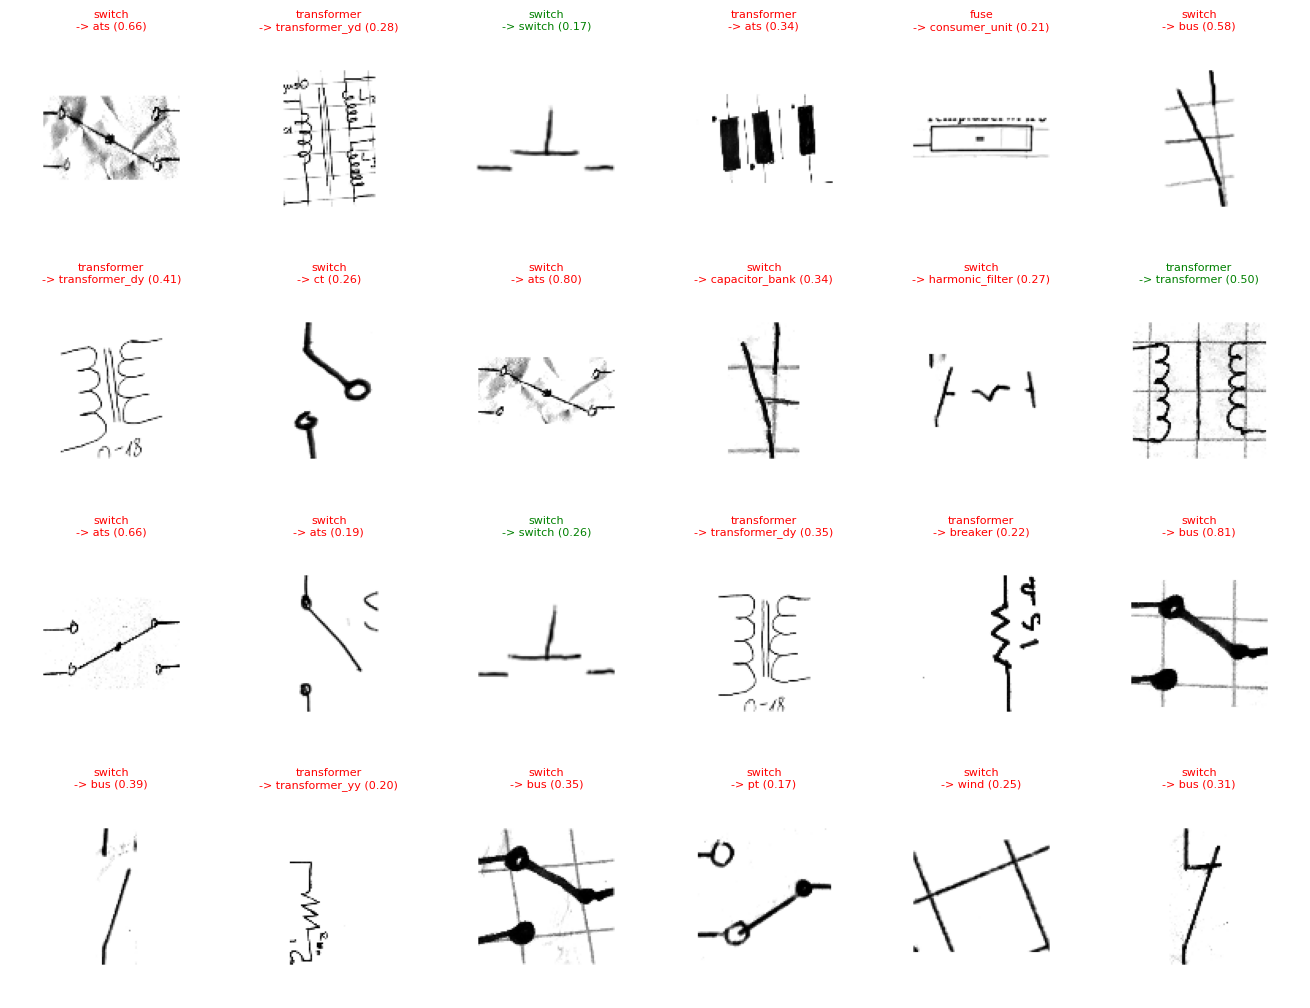

In [41]:
# 5.6 look at the (normalised) test crops with predictions (in-kernel)
import importlib, json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from collections import Counter

import config, data, model as _m
importlib.reload(config); importlib.reload(data)

_, _, class_names, _ = data.load_datasets()
test_ds = data.load_external_test_dataset(class_names)
net = tf.keras.models.load_model(str(config.MODEL_DIR / f"{model_tag}.keras"), compile=False)

rows = data.read_manifest(config.TEST_MANIFEST_PATH)
images, y_true, y_pred, conf = [], [], [], []
for x, y in test_ds:
    p = tf.nn.softmax(net(x, training=False), -1).numpy()
    images.append(x.numpy()); y_true.append(np.argmax(y.numpy(), -1))
    y_pred.append(np.argmax(p, -1)); conf.append(p.max(-1))
images, y_true, y_pred, conf = map(np.concatenate, (images, y_true, y_pred, conf))

print(f"accuracy: {np.mean(y_true == y_pred):.3f}  on {len(y_true)} crops")
print("per-class support:", Counter(class_names[t] for t in y_true))
print("per-class accuracy:")
for c in sorted(set(y_true)):
    m = y_true == c
    print(f"  {class_names[c]:<14} {np.mean(y_pred[m] == c):.2f}  (n={m.sum()})")

n = min(24, len(images))
idx = np.random.RandomState(0).choice(len(images), n, replace=False)
cols = 6
fig, axes = plt.subplots(int(np.ceil(n / cols)), cols, figsize=(2.2 * cols, 2.6 * np.ceil(n / cols)))
for ax, i in zip(axes.flat, idx):
    ax.imshow(255 - images[i].squeeze(), cmap="gray")
    ok = y_true[i] == y_pred[i]
    ax.set_title(f"{class_names[y_true[i]]}\n-> {class_names[y_pred[i]]} ({conf[i]:.2f})",
                 fontsize=8, color="green" if ok else "red")
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()


In [42]:
# 5.7 keep the test artefacts with the training outputs
import shutil
from pathlib import Path
out = Path("/kaggle/working/component_train_outputs")
for name in ("models", "outputs"):
    src = TRAIN_DIR / name
    if src.exists():
        shutil.copytree(src, out / name, dirs_exist_ok=True)
print(sorted(p.name for p in (out / "outputs").glob("*cghd*")))


[]
